# Examen Final – Module 3 : Python pour l’Analyse de Données 

## 1. Chargement et exploration initiale 

In [1]:
# importation des librairies:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# Importez le fichier Excel dans un DataFrame nommé df
df=pd.read_excel(r"..\DATA/funpark_data.xlsx")
# Affichez les 5 premières lignes
df.head()
# Affichez les informations générales sur les données
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Visiteur             2505 non-null   object
 1   Email                2505 non-null   object
 2   Pays                 2505 non-null   object
 3   Type_Billet          2505 non-null   object
 4   Âge                  2362 non-null   object
 5   Prix_Billet          2411 non-null   object
 6   Dépenses_Restaurant  2403 non-null   object
 7   Description          2505 non-null   object
 8   Date_Visite          2505 non-null   object
 9   Période              2505 non-null   object
dtypes: object(10)
memory usage: 195.8+ KB


,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période
0,tom gonzalez,tom.gonzalez1447@yahoo.fr,France,std,30,NaN,26.87,Churros,2025-01-04,Avant
1,Zoe Gonzalez,zoe.gonzalez1114@outlook.com,Maroc,Etud,25,24.18,4.55,Menu Enfant,2025-04-11,Après
2,Lina Gonzalez,lina.gonzalez1064@gmail.com,Espagne,Standard,48,43.14,11.7,Glace Vanille,2025-03-25,Après
3,Fatima Lefevre,fatima.lefevre2287@mail.com,Allemagne,std,33,49.58,12.33,Café Espresso,2025-02-04,Avant
4,Sami Diaz,sami.diaz1537@gmail.com,Espagne,STD,18,57.25,13.06,Gaufre,2025-06-18,Après



* Les données du funpark sont composées de 2505 lignes et 10 colonnes, toutes les colonnes sont de type texte 
* La colonne Age contient 143 valeurs manquantes
* La colonne Prix_Billet contient 94 valeurs manquantes
* La colonne Dépenses_Restaurant contient 102 valeurs manquantes
* Et les autres colonnes ne contiennent aucune valeur manquantes
* Le stockage mémoire est à 195.8kB 



## 2. Qualité et fiabilisation des données

### 2.1.Nettoyez les colonnes

In [3]:
# Nettoyez les colonnes 
# On crée une copie de la data frame original pour faire le nettoyage et on le nomme df_clean
df_clean=df.copy()
# Nettoyage des colonnes de type texte:
# Enlever les espaces avant et après avec la méthode strip
df_clean["Visiteur"]=df_clean["Visiteur"].str.strip().str.lower()
df_clean["Email"]=df_clean["Email"].str.strip()
df_clean["Pays"]=df_clean["Pays"].str.strip()
df_clean["Type_Billet"]=df_clean["Type_Billet"].str.strip()
df_clean["Description"]=df_clean["Description"].str.strip()
# Dans cette section on utilise la méthode title qui sert à mettre la première lettre en Maj:
df_clean["Visiteur"]=df_clean["Visiteur"].str.title() # La colonne visiteur sous forme Nom Prénom
df_clean["Pays"]=df_clean["Pays"].str.title()
df_clean["Description"]=df_clean["Description"].str.title()
df_clean.head()# Verification que les données sont bien nettoyées

,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période
0,Tom Gonzalez,tom.gonzalez1447@yahoo.fr,France,std,30,NaN,26.87,Churros,2025-01-04,Avant
1,Zoe Gonzalez,zoe.gonzalez1114@outlook.com,Maroc,Etud,25,24.18,4.55,Menu Enfant,2025-04-11,Après
2,Lina Gonzalez,lina.gonzalez1064@gmail.com,Espagne,Standard,48,43.14,11.7,Glace Vanille,2025-03-25,Après
3,Fatima Lefevre,fatima.lefevre2287@mail.com,Allemagne,std,33,49.58,12.33,Café Espresso,2025-02-04,Avant
4,Sami Diaz,sami.diaz1537@gmail.com,Espagne,STD,18,57.25,13.06,Gaufre,2025-06-18,Après


### 2.2.Uniformisez les modalités de la colonne Type_Billet


In [4]:
# Avec la méthode unique on affiche tout les type de billet qui existent la colonne 
df_clean["Type_Billet"].unique()
df_clean["Type_Billet"]=df_clean["Type_Billet"].replace({"std":"Standard","STD":"Standard","standard":"Standard","Etud":"Etudiant","etudiant":"Etudiant","ETUDIANT":"Etudiant","étudiant":"Etudiant","vip":"VIP","Vip":"VIP","billet vip":"VIP","V I P":"VIP","fam":"Famille","Fam":"Famille","FAMILLE":"Famille","famille":"Famille"})
df_clean["Type_Billet"].nunique()# On a 4 type de billet: Standard, Etudiant,Famille,VIP

4

### 2.3.Convertissez les colonnes dans le bon type

In [5]:
# conversion les colonnes Age et prix_billet et depenses_Restaurant en type numerique :
df_clean["Âge"] = pd.to_numeric(df_clean["Âge"], errors="coerce")
df_clean["Prix_Billet"] = pd.to_numeric(df_clean["Prix_Billet"],errors="coerce")
df_clean["Dépenses_Restaurant"] = pd.to_numeric(df_clean["Dépenses_Restaurant"],errors="coerce")
# conversion la colonne Date_Visite en type Date avec formmat jour_mois_année 
df_clean['Date_Visite'] = pd.to_datetime(df_clean['Date_Visite'], errors='coerce',format="%Y-%m-%d")
# conversion la colonne Type_Billet en type catégorie
df_clean['Type_Billet'] = df_clean['Type_Billet'].astype('category')
df_clean['Période'] = df_clean['Période'].astype('category')
df_clean.dtypes


Visiteur                       object
Email                          object
Pays                           object
Type_Billet                  category
Âge                           float64
Prix_Billet                   float64
Dépenses_Restaurant           float64
Description                    object
Date_Visite            datetime64[ns]
Période                      category
dtype: object

### 2.3.Traitez les valeurs manquantes.

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Visiteur             2505 non-null   object        
 1   Email                2505 non-null   object        
 2   Pays                 2505 non-null   object        
 3   Type_Billet          2505 non-null   category      
 4   Âge                  2361 non-null   float64       
 5   Prix_Billet          2410 non-null   float64       
 6   Dépenses_Restaurant  2393 non-null   float64       
 7   Description          2505 non-null   object        
 8   Date_Visite          2505 non-null   datetime64[ns]
 9   Période              2505 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(3), object(4)
memory usage: 161.9+ KB


In [7]:
#Les valeurs manquantes sont remplacées par la méthode fillna, dans notre cas nous avons 3 colonnes avec des valeurs manquantes
# On remplace les valeurs manquantes des colonne Age et Dépenses_Restaurant par la mediane
df_clean["Âge"]=df_clean["Âge"].fillna(df_clean["Âge"].median())
df_clean["Dépenses_Restaurant"]=df_clean["Dépenses_Restaurant"].fillna(df_clean["Dépenses_Restaurant"].median())
# On remplace les valeurs manquantes de la colonne Prix_Billet par la valeur la plus fréquente avec la methode mode car le prix du billet correspond à des tarifs selon le type de billet
df_clean["Prix_Billet"]=df_clean["Prix_Billet"].fillna(df_clean["Prix_Billet"].mode()[0])
# Verification : aucune colonne ne contient des valeurs manquantes 
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Visiteur             2505 non-null   object        
 1   Email                2505 non-null   object        
 2   Pays                 2505 non-null   object        
 3   Type_Billet          2505 non-null   category      
 4   Âge                  2505 non-null   float64       
 5   Prix_Billet          2505 non-null   float64       
 6   Dépenses_Restaurant  2505 non-null   float64       
 7   Description          2505 non-null   object        
 8   Date_Visite          2505 non-null   datetime64[ns]
 9   Période              2505 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(3), object(4)
memory usage: 161.9+ KB


### 2.4. Supprimez les doublons exacts basés sur Visiteur, Email et Date_Visite 

In [8]:
# compter combien de ligne doublée dans notre data 
df_clean.duplicated(subset=["Visiteur","Email","Date_Visite"]).sum()# 5 lignes répétées
# supprimer les doublons
df_clean=df_clean.drop_duplicates(subset=["Visiteur","Email","Date_Visite"])# nous avons supprimé 5 lignes


### 2.5.Détectez et traitez les valeurs aberrantes

 Pour prix_billet: Q1=39.2725 , Q3=91.94 et IQR=52.6675 
 Pour dépenses restaurant Q1=8.14 , Q3=21.74 et IQR=13.599999999999998 
Valeurs aberrantes détectées prix billet :
             Visiteur                          Email       Pays Type_Billet  \
309       Emma Garcia      emma.garcia1337@gmail.com  Allemagne    Standard   
611      Paul Fischer       paul.fischer203@yahoo.fr    Espagne    Standard   
1028         Bob Ruiz          bob.ruiz2418@mail.com  Allemagne     Famille   
1476     Kenza Muller      kenza.muller1641@mail.com    Espagne    Standard   
1844      Jules Silva    jules.silva2210@outlook.com     France         VIP   
1992      Paul Moreau    paul.moreau1155@outlook.com  Allemagne    Standard   
2118  Rania Fernandez  rania.fernandez2070@gmail.com     France    Standard   
2456         Zoe Ruiz          zoe.ruiz1478@mail.com      Maroc         VIP   

       Âge  Prix_Billet  Dépenses_Restaurant       Description Date_Visite  \
309   39.0   256.423413               

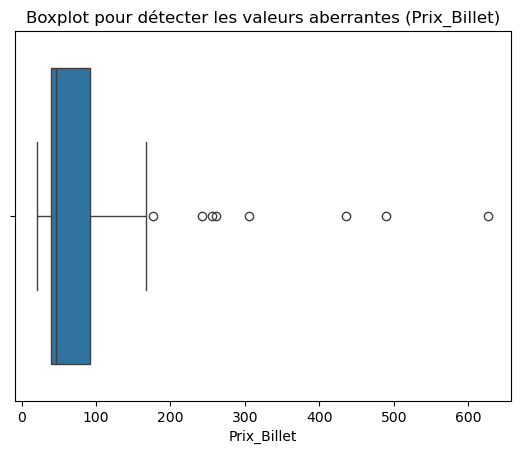

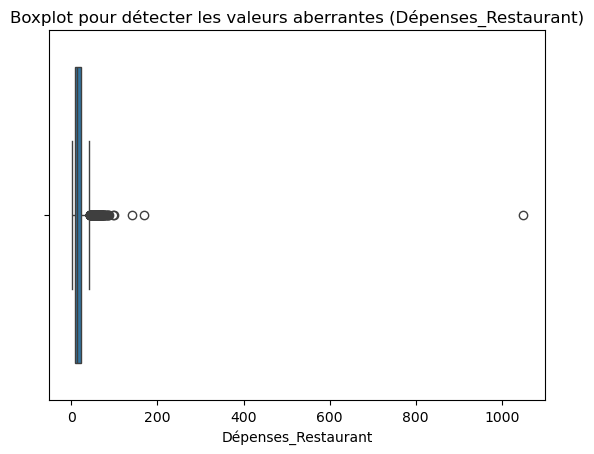

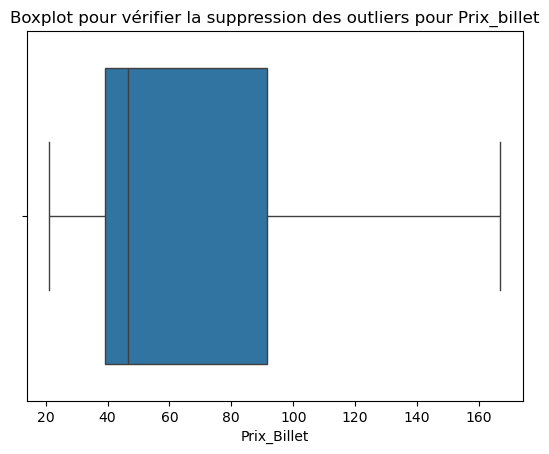

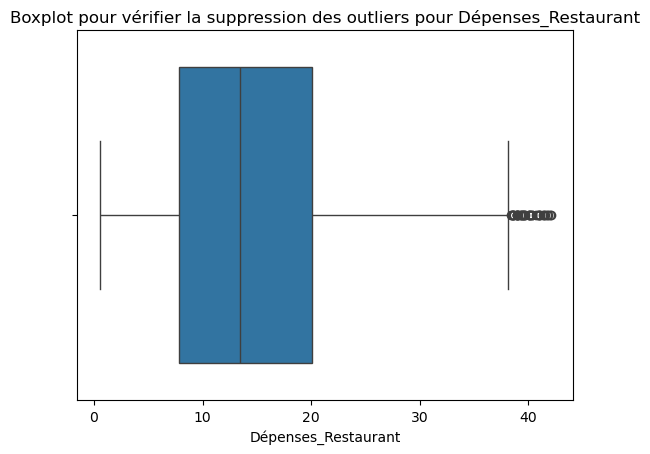

 Pour dépenses restaurant Q1=7.8625 , Q3=20.04 et IQR=12.177499999999998 
Valeurs aberrantes détectées Dépenses_Restaurant :
             Visiteur                           Email       Pays Type_Billet  \
87      Alice Lefevre  quentin.fernandez630@gmail.com      Maroc     Famille   
142     David Bennani      david.bennani1080@yahoo.fr  Allemagne     Famille   
204     Rania Fischer      rania.fischer1061@yahoo.fr     France         VIP   
215      Sami Schmidt       sami.schmidt1901@mail.com     France    Standard   
235      Inès Fischer        inès.fischer632@yahoo.fr     France    Etudiant   
328      Jules Haddad         jules.haddad69@mail.com     France     Famille   
329       Sami Muller         sami.muller443@yahoo.fr     France     Famille   
354    Quentin Haddad     quentin.haddad2026@mail.com  Allemagne         VIP   
491     Alice Schmidt     alice.schmidt1637@gmail.com     France         VIP   
522         Inès Diaz          alice.diaz348@mail.com     France    Standar

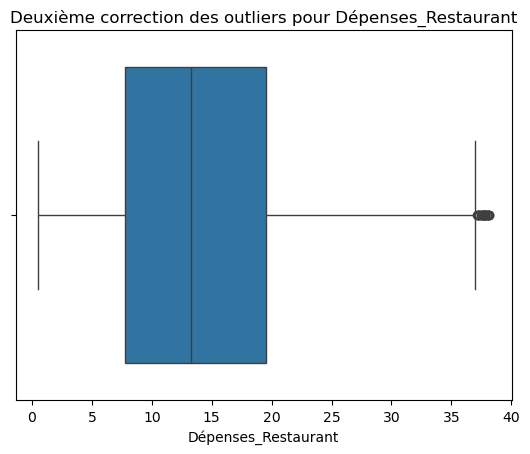

In [9]:
#Les valeurs aberrantes pour Prix_Billet
Q1_prix = df_clean["Prix_Billet"].quantile(0.25)
Q3_prix = df_clean["Prix_Billet"].quantile(0.75)
IQR_prix = Q3_prix - Q1_prix
print(f' Pour prix_billet: Q1={Q1_prix} , Q3={Q3_prix} et IQR={IQR_prix} ')


#Les valeurs aberrantes pour Dépenses_Restaurant
Q1_depenses = df_clean["Dépenses_Restaurant"].quantile(0.25)
Q3_depenses = df_clean["Dépenses_Restaurant"].quantile(0.75)
IQR_depenses = Q3_depenses - Q1_depenses
print(f' Pour dépenses restaurant Q1={Q1_depenses} , Q3={Q3_depenses} et IQR={IQR_depenses} ')

# Détection des outliers pour prix billet
outliers_prix = df_clean[(df_clean["Prix_Billet"] < Q1_prix - 1.5 * IQR_prix) | (df_clean["Prix_Billet"] > Q3_prix + 1.5 * IQR_prix)]

# Affichage des outliers détectés
print("Valeurs aberrantes détectées prix billet :")
print(outliers_prix)

# Détection des outliers pour depenses restaurant 
outliers_depenses = df_clean[(df_clean["Dépenses_Restaurant"] < Q1_depenses - 1.5 * IQR_depenses) | (df_clean["Dépenses_Restaurant"] > Q3_depenses + 1.5 * IQR_depenses)]

# Affichage des outliers détectés
print("Valeurs aberrantes détectées Dépenses_Restaurant :")
print(outliers_depenses)


# Visualisation des outliers prix billet avec un boxplot
sns.boxplot(x=df_clean["Prix_Billet"])
plt.title("Boxplot pour détecter les valeurs aberrantes (Prix_Billet)")
plt.show()

# Visualisation des outliers Dépenses_Restaurant avec un boxplot
sns.boxplot(x=df_clean["Dépenses_Restaurant"])
plt.title("Boxplot pour détecter les valeurs aberrantes (Dépenses_Restaurant)")
plt.show()

# Traitement des outliers

#Supprimez les outliers pour prix billet pour obtenir un jeu de données propre
df_sans_outliers_prix = df_clean[~df_clean.index.isin(outliers_prix.index)]
df_sans_outliers_depenses = df_clean[~df_clean.index.isin(outliers_depenses.index)]

# Verification graphique de la suppression des outliers pour prix_billet
sns.boxplot(x=df_sans_outliers_prix["Prix_Billet"])
plt.title("Boxplot pour vérifier la suppression des outliers pour Prix_billet")
plt.show()

# Verification graphique de la suppression des outliers pour depenses
sns.boxplot(x=df_sans_outliers_depenses["Dépenses_Restaurant"])
plt.title("Boxplot pour vérifier la suppression des outliers pour Dépenses_Restaurant")
plt.show()

# Deuxième correction de Dépenses_Restaurant
#Les valeurs aberrantes pour Dépenses_Restaurant
Q1_p2_depenses = df_sans_outliers_depenses["Dépenses_Restaurant"].quantile(0.25)
Q3_p2_depenses = df_sans_outliers_depenses["Dépenses_Restaurant"].quantile(0.75)
IQR_p2_depenses = Q3_p2_depenses - Q1_p2_depenses
print(f' Pour dépenses restaurant Q1={Q1_p2_depenses} , Q3={Q3_p2_depenses} et IQR={IQR_p2_depenses} ')

# Détection des outliers pour prix billet
outliers_p2_depenses = df_sans_outliers_depenses[(df_sans_outliers_depenses["Dépenses_Restaurant"] < Q1_p2_depenses - 1.5 * IQR_p2_depenses) | (df_sans_outliers_depenses["Dépenses_Restaurant"] > Q3_p2_depenses + 1.5 * IQR_p2_depenses)]
df_sans_outliers_p2_depenses = df_sans_outliers_depenses[~df_sans_outliers_depenses.index.isin(outliers_p2_depenses.index)]
print("Valeurs aberrantes détectées Dépenses_Restaurant :")
print(outliers_p2_depenses)
sns.boxplot(x=df_sans_outliers_p2_depenses["Dépenses_Restaurant"])
plt.title("Deuxième correction des outliers pour Dépenses_Restaurant")
plt.show()



Pour prix billet 
* Avant traitement, le boxplot de prix_billet montrait plusieurs valeurs aberrantes très élevées, cela inidiquait la présence
de billets anormalement chers par rapport à la majorité des observations 
* Après traitement, le boxplot est devenu plus homogène et ne montre plus de valeurs aberrantes visibles, les prix de billets sont désormais dans une plage plus cohérente

Pour dépenses restaurant
* Avant traitement le boxplot de depenses restaurant montrait plusieurs valeurs aberrantes ce qui montrait
que certaines dépenses étaient nettement supérieures au comportement habituel de la variable
* Après le premier traitement on remarque toujours la présence de quelques valeurs aberrantes, certaines valeurs qui n'etaient pas considéréers comme aberrantes ce qui a nécessité une deuxième correction  pour un jeu de données plus propre.

* Après ce deuxième traitement, la distribution est devenue plus propre et plus stable la majorité des valeurs aberrantes ont été supprimées et les dépenses restaurant sont plus homogène

### 2.6.Affichez les informations générales de vos données

In [10]:
print(df.info())
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Visiteur             2505 non-null   object
 1   Email                2505 non-null   object
 2   Pays                 2505 non-null   object
 3   Type_Billet          2505 non-null   object
 4   Âge                  2362 non-null   object
 5   Prix_Billet          2411 non-null   object
 6   Dépenses_Restaurant  2403 non-null   object
 7   Description          2505 non-null   object
 8   Date_Visite          2505 non-null   object
 9   Période              2505 non-null   object
dtypes: object(10)
memory usage: 195.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Visiteur             2500 non-null  

Comparaison


Après le traitement, le jeu de données est plus propre plus coherent, les colonnes ont été converties dans les bons types, 
les valeurs manuquantes ont été traitées, les doublons ont été supprimées, on est passé de 2505 à 2500 lignes, les valeurs aberrantes ont été retirées, on remarque aussi que le stockage mémoire a diminué en passant de 195.8KB à 181 KB ce qui mobtre que les données
nettoyées occupent moins d'espace.


## 3.Analyse des profils visiteurs et comportements d’achats

In [11]:
# Créez une nouvelle colonne Revenue_Total
df_clean["Revenue_Total"]=(df_clean["Prix_Billet"] + df_clean["Dépenses_Restaurant"]).round(2)
df_clean.head()
# la répartition des visiteurs par pays
print(df_clean["Pays"].value_counts())
# la répartition des visiteurs par Type_Billet
print(df_clean["Type_Billet"].value_counts())

Pays
France       1032
Espagne       712
Allemagne     519
Maroc         237
Name: count, dtype: int64
Type_Billet
Standard    1152
VIP          535
Etudiant     494
Famille      319
Name: count, dtype: int64


In [12]:
#la dépense totale moyenne par visiteur
print(df_clean.groupby("Visiteur")["Revenue_Total"].mean().round(2))

Visiteur
Alice Bennani     78.94
Alice Bernard    101.30
Alice Diaz       110.51
Alice Dupont      89.87
Alice Durand      80.22
                  ...  
Zoe Rossi         57.58
Zoe Ruiz         140.15
Zoe Schmidt       76.69
Zoe Silva        102.04
Zoe Weber         77.51
Name: Revenue_Total, Length: 440, dtype: float64


In [13]:
#la dépense totale moyenne par Type_Billet
print(df_clean.groupby("Type_Billet")["Revenue_Total"].mean().round(2))

Type_Billet
Etudiant     45.10
Famille     144.46
Standard     60.00
VIP         116.96
Name: Revenue_Total, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_17540\4212110949.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby("Type_Billet")["Revenue_Total"].mean().round(2))


In [14]:
#  les 5 produits les plus vendus et donnez leur revenu moyen
Top5=df_clean["Description"].value_counts().head(5)
print(Top5)
# le revenu moyen pour chaque description
print(df_clean[df_clean["Description"].isin(Top5.index)].groupby("Description")["Revenue_Total"].mean().round(2))

Description
Menu Enfant        205
Café Espresso      188
Sandwich Thon      178
Glace Vanille      172
Smoothie Fraise    170
Name: count, dtype: int64
Description
Café Espresso      79.46
Glace Vanille      78.99
Menu Enfant        84.83
Sandwich Thon      81.04
Smoothie Fraise    75.56
Name: Revenue_Total, dtype: float64


In [15]:
# le pays avec le plus grand nombre de visiteurs et celui avec le plus faible nombre
pays_index_max=df_clean["Pays"].value_counts().sort_values(ascending=False).index[0]
pays_index_min=df_clean["Pays"].value_counts().sort_values(ascending=False).index[-1]
pays_value_max=df_clean["Pays"].value_counts().sort_values(ascending=False).values[0]
pays_value_min=df_clean["Pays"].value_counts().sort_values(ascending=False).values[-1]
print("Le pays avec le plus grand nombre de visiteurs ",pays_index_max,"avec",pays_value_max,"visiteurs")
print("Le pays avec le plus faible nombre de visiteurs",pays_index_min,"avec",pays_value_min,"visiteurs")

Le pays avec le plus grand nombre de visiteurs  France avec 1032 visiteurs
Le pays avec le plus faible nombre de visiteurs Maroc avec 237 visiteurs


In [16]:
# Calculez l’âge médian des visiteurs par type de billet
print(df_clean.groupby("Type_Billet")["Âge"].median())

Type_Billet
Etudiant    31.0
Famille     31.0
Standard    31.0
VIP         31.0
Name: Âge, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_17540\415922663.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby("Type_Billet")["Âge"].median())


In [17]:
# Classez les pays selon le revenu total moyen (du plus élevé au plus faible). 
df_clean.head(10)
print(df_clean.groupby("Pays")["Revenue_Total"].mean().round(2).sort_values(ascending=False))

Pays
France       82.62
Allemagne    80.01
Espagne      78.71
Maroc        72.66
Name: Revenue_Total, dtype: float64


In [18]:
# Créez 4 groupes de visiteurs en fonction de leur Revenu_Total avec qcut 
Group_Revenu=pd.qcut(df_clean['Revenue_Total'], q=4)
#affichez le nombre de visiteurs dans chaque groupe. 
print(Group_Revenu.value_counts())

Revenue_Total
(61.275, 109.6]                 626
(24.238999999999997, 49.935]    625
(49.935, 61.275]                625
(109.6, 1137.73]                624
Name: count, dtype: int64


In [19]:
# Affichez les 10 visiteurs ayant généré le plus de Revenu_Total
df_clean.groupby("Visiteur")["Revenue_Total"].sum().round(2).sort_values(ascending=False).head(10)

Visiteur
Fatima Haddad     1339.30
Kenza Silva       1172.15
Sami Muller       1167.72
Bob Ruiz          1146.70
Yasmine Durand    1079.40
Inès Ruiz         1072.89
Jules Schmidt     1024.91
Fatima Muller      971.39
Yasmine Silva      949.17
Alice Gonzalez     937.23
Name: Revenue_Total, dtype: float64

In [20]:
def classer_age(age):
    if age<18:
        return "Mineur"
    elif 18<=age<= 30:
        return "Jeune adulte"
    elif 31<=age<= 50:
        return "Adulte"
    else:
        return"Senior"
     

In [22]:
#Appliquez cette fonction à la colonne Âge pour créer une nouvelle colonne Classe_Age
df_clean["Classe_Age"] = df_clean["Âge"].apply(classer_age)
df_clean.head()

,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période,Revenue_Total,Classe_Age
0,Tom Gonzalez,tom.gonzalez1447@yahoo.fr,France,Standard,30.0,41.76,26.87,Churros,2025-01-04,Avant,68.63,Jeune adulte
1,Zoe Gonzalez,zoe.gonzalez1114@outlook.com,Maroc,Etudiant,25.0,24.18,4.55,Menu Enfant,2025-04-11,Après,28.73,Jeune adulte
2,Lina Gonzalez,lina.gonzalez1064@gmail.com,Espagne,Standard,48.0,43.14,11.70,Glace Vanille,2025-03-25,Après,54.84,Adulte
3,Fatima Lefevre,fatima.lefevre2287@mail.com,Allemagne,Standard,33.0,49.58,12.33,Café Espresso,2025-02-04,Avant,61.91,Adulte
4,Sami Diaz,sami.diaz1537@gmail.com,Espagne,Standard,18.0,57.25,13.06,Gaufre,2025-06-18,Après,70.31,Jeune adulte


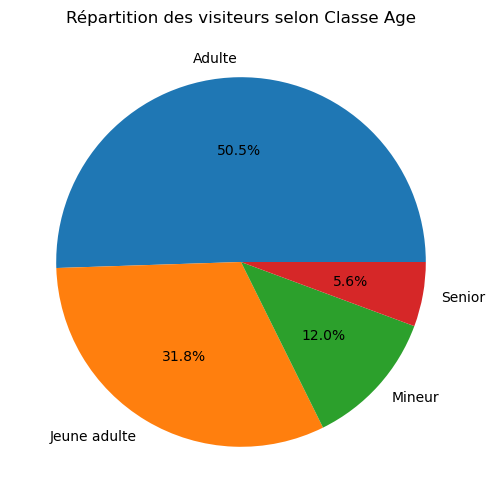

In [23]:
# Représentez graphiquement la répartition des visiteurs selon Classe_Age à l’aide d’un camembert.
plt.figure(figsize=(6,6)) # On gère la taille du graphique 
df_clean['Classe_Age'].value_counts().plot.pie(autopct='%1.1f%%') # On trace notre camembert en utilisant le comptage des type d'item
plt.title('Répartition des visiteurs selon Classe Age')
plt.ylabel('')
plt.show()

D'après la répartition, on observe que les visiteurs de catégorie Adulte sont plus présent dans le funpark, et la catégorie senior est la catégorie la moins présente

In [24]:
# Exportez votre df dans un fichier Excel que vous nommerez data_cleaned_nom_prenom.xlsx 
df_clean.to_excel("../OUTPUT/Data_cleaned_louhab_rania.xlsx", index=False)

## 4.Impact de la campagne promotionnelle

### 4.1.Séparez les données en deux sous-ensembles : Avant et Après la promotion

In [26]:
df_avant_promo=df_clean[df_clean["Période"]=="Avant"]
df_apres_promo=df_clean[df_clean["Période"]=="Après"]

### 4.2.Pour chaque période, calculez la moyenne, la médiane et l’écart-type du Revenu_Total. 

In [27]:
# Pour la période avant promo:
#La moyenne
print("La moyenne des revenues totaux avant promo est: ",df_avant_promo["Revenue_Total"].mean().round(2))
# La médiane
print("La médiane des revenues totaux avant promo est: ",round(df_avant_promo["Revenue_Total"].median(),2))
# L'ecart-type
print("L'ecart-type des revenues totaux avant promo est: ",round(df_avant_promo["Revenue_Total"].std(),2))

La moyenne des revenues totaux avant promo est:  77.7
La médiane des revenues totaux avant promo est:  59.98
L'ecart-type des revenues totaux avant promo est:  40.88


In [28]:
# Pour la période après promo période:
#La moyenne
print("La moyenne des revenues totaux après promo est: ",df_apres_promo["Revenue_Total"].mean().round(2))
# La médiane
print("La médiane des revenues totaux après promo est: ",round(df_apres_promo["Revenue_Total"].median(),2))
# L'ecart-type
print("L'ecart-type des revenues totaux après promo est: ",round(df_apres_promo["Revenue_Total"].std(),2))

La moyenne des revenues totaux après promo est:  81.52
La médiane des revenues totaux après promo est:  62.98
L'ecart-type des revenues totaux après promo est:  51.49


**Interpretation des résultats**:
* Après la promotion , on remarque que Le revenu moyen a augmenté d'environ 4,92% ,
* La médiane évolue dans le même sens de 61.14 à 64.25, l'augmentation ne repose pas que sur les valeurs extrêmes.
* et le coefficient de variation a augmenté de 52% à 62% ce qui indique une dispersion importante des revenus sur cette période

**Conclusion** :
* On peut conclure à partir de ces deux observations, qu'après avoir mis en place les trois initiative le revenu moyen du funpark a légèrement augmenté.Toutefois l'augmentation de l'ecart-type indique une augmentation de dispersions ce qui montre que les résultats sont plus variables qu'avant.

* Cela soutient l'hypothèse selon laquelle les initiatives mises en place par le funpark ont pu avoir un effet positif sur le revenu moyen mais avec une instabilité des revenus.cette hypothèse devra être confirmée par un test statistique. 


## 4.3.Représentez la distribution des revenus totaux par période avec un histogramme.

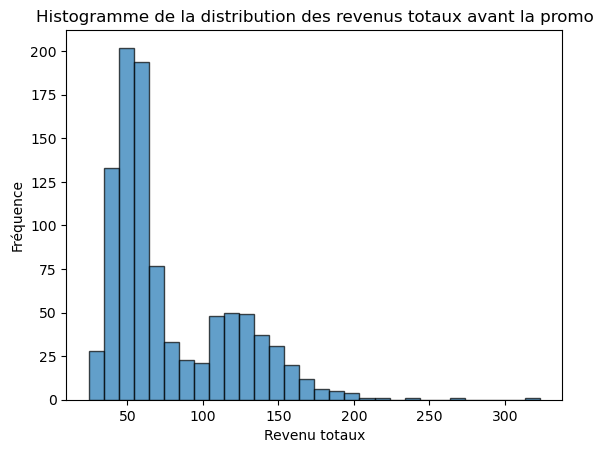

In [29]:
# Tracer l'histogramme de la distribution des revenus totaux avant promo
plt.hist(df_avant_promo["Revenue_Total"], bins=30, edgecolor='black', alpha=0.7)
plt.title("Histogramme de la distribution des revenus totaux avant la promo")
plt.xlabel("Revenu totaux")
plt.ylabel("Fréquence")
plt.show()

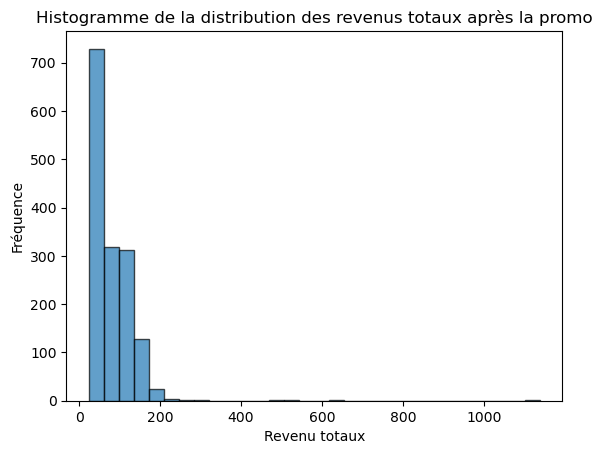

In [30]:
# Tracer l'histogramme de la distribution des revenus totaux apres promo
plt.hist(df_apres_promo["Revenue_Total"], bins=30, edgecolor='black', alpha=0.7)
plt.title("Histogramme de la distribution des revenus totaux après la promo")
plt.xlabel("Revenu totaux")
plt.ylabel("Fréquence")
plt.show()

**Observation**


D'après les deux histogrammes on observe que:
* Avant la promotion, la distribution des revenus totaux est asymétrique à droite avec quelques valeurs élevées
* Après la promotion,la distribution reste asymétrique à droite, mais elle semble légèrment décalée vers des revenus plus élevés ce qui est cohérent avec l'augmentation de la moyenne mais aussi plus dispersés, cela confirme une amélioration modérée du revenu moyen, accompagnée d'une plus grande variabilité


### 4.3.Réalisez un test statistique pour comparer les revenus totaux moyens avant et après la promotion

Pour comparer les revenus totaux moyens avant et après la promo, j'ai opté pour **le test student** car l'objectif est de
comparer deux groupes et comme il s'agit de deux échantillons distincts, ce test est le plus adapté

In [31]:
t_stat, p_value = stats.ttest_ind(df_avant_promo["Revenue_Total"], df_apres_promo["Revenue_Total"])
# Résultats
print(f"T-statistique : {t_stat:.4f}")
print(f"P-valeur : {p_value:.4f}")

T-statistique : -1.9566
P-valeur : 0.0505


### 4.4.Indiquez si la différence est statistiquement significative au seuil de 5 % et interprétez le résultat pour la direction.

Résultat du test de Student


**T-statistique** : -1.9566


**P-valeur** :0.0505


Interprétation statistique:


La p-valeur > 0.05 :
→ Cela signifie que la différence entre les revenus totaux moyens avant et après la promo n'est pas statistiquement significative
au seuil de 5%, même si la moyenne après la promo est plus élevée on ne peut pas conclure que cette hausse est due à la campagne promotionnelle

## 5. Recommandations stratégiques

### 5.1.Le billet VIP est-il attractif ? 

In [32]:
df_clean["Type_Billet"].value_counts()

Type_Billet
Standard    1152
VIP          535
Etudiant     494
Famille      319
Name: count, dtype: int64

Le billet VIP semble attractif puisqu'il représente le deuxième type de billet le plus acheté au funpark avec 535 achats, c'est donc une offre intéressante pour contribuer à progresser le revenu moyen du parc. Cependant le billet standard reste le plus attractif auprès des visiteurs avec 1152 achats

### 5.2.La campagne promotionnelle a-t-elle eu un effet mesurable ? 

D'après l'analyse effectuée, on voit une légère augmentation du revenu moyen après la mise en place de la compagne.Cependant le test statistique ne montre pas de différence significative entre les périodes avant et après. On ne peut pas conclure que la compagne a eu un effet mesurable sur le revenu moyen du funpark


### 5.3.Quelles actions prioritaires conseilleriez-vous pour améliorer les revenus et l’expérience des visiteurs ?

D'après la répartition des visiteurs par classe age, les catégories les plus représentées sont les adultes et les jeunes adultes


* Je conseillerais donc de proposer des offres pour ces publics, par exemple des billets de groupe ou des réductions étudiantes
pendant les vacances scolaires.
* Le parc peut profiter des weekends ou des jour fériés pour ajouter des activités comme des concerts, des animations saisonières
afin d'attirer davantage des visiteurs
* Améliorer les zones aquatique, ajouter plus d'animations et proposer des billets famille aqua donnant accés aux attractions aquatiques, notamment pendant la période estivale.
* On remarque aussi que l'offre VIP est classée le deuxième type billet le plus acheté, donc il est attractif, le parc peut enrichir cette offre en incluant  une réduction sur des menus enfant pour quelque restaurants afin d'augmenter le revenu moyen et améliorer l'éxpérience des visiteurs.
 
                